In [1]:
# ── Core libraries ────────────────────────────────────────────────────────────
import os
import re
import string
import warnings
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#e8e8e8",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
})

PALETTE    = {"ham": "#1D9E75", "spam": "#D85A30"}
STOP_WORDS = set(stopwords.words('english'))

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [2]:
# data loading
data_path =r'/workspaces/Spam-Classifier/data/raw/SMS-Spam'
print(f"Files exists:{os.path.exists(data_path)}")

Files exists:True


In [3]:
# read data
df = pd.read_csv(data_path, sep="\t", header=None, names=["label", "text"])

print(f"(Rows, Columns)  : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
df.head()

(Rows, Columns)  : (5572, 2)
Columns    : ['label', 'text']


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
#  Data types & memory usage 
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

label    str
text     str
dtype: object

Memory usage: 1000.7 KB


In [5]:
  # class distribution

print("label distribution:")
print(df['label'].value_counts())
print(f"\nSpam ratio: {df['label'].eq('spam').mean()*100:.1f}%")


label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam ratio: 13.4%


CLEANING START

In [6]:
# CHECK MISSING VALUES
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nShape after null drop: {df.shape}")
print("---------------------------------")
print("checking duplicates...")
print("---------------------------------")

# CHECK DUPLICATE ENTRIES
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"Duplicate entries before: {before}")
print(f"Duplicate entries after: {after}")
print(f"Duplicates removed: {before - after}")


Missing values per column:
label    0
text     0
dtype: int64

Shape after null drop: (5572, 2)
---------------------------------
checking duplicates...
---------------------------------
Duplicate entries before: 5572
Duplicate entries after: 5169
Duplicates removed: 403


In [7]:
# Encoding labels
# HAM = 0, SPAM = 1
df['label_num']= df['label'].map({'ham':0, 'spam':1})
print(df.head())

  label                                               text  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


    Full NLP preprocessing pipeline:
      1. Lowercase
      2. Remove URLs
      3. Remove digits
      4. Remove punctuation
      5. Strip extra whitespace
      6. Remove stopwords and single characters


In [8]:
# Text Cleaning

def clean_text(text):

    text=text.lower() # convert to lowercase
    text=re.sub(r"http\S+|www\S+", " ", text) # remove URLs
    text=re.sub(r"\d+", " ", text) # remove numbers
    text=text.translate(str.maketrans("", "", string.punctuation)) # remove punctuation
    text=re.sub(r"\s+", " ", text).strip() # remove extra whitespace   
    tokens=text.split() # tokenize
    tokens=[t for t in tokens if t not in STOP_WORDS and len(t) > 1] # remove stopwords and single characters
    return " ".join(tokens) 

# Apply to dataframe 
df['clean_text'] = df['text'].apply(clean_text)
print("Sample — original vs cleaned:")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"  ORIGINAL : {row['text'][:80]}")
    print(f"  CLEANED  : {row['clean_text'][:80]}")
    print()


Sample — original vs cleaned:
  ORIGINAL : K, makes sense, btw carlos is being difficult so you guys are gonna smoke while 
  CLEANED  : makes sense btw carlos difficult guys gonna smoke go pick second batch get gas

  ORIGINAL : URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! 
  CLEANED  : urgent mobile bonus caller prize nd attempt reach call asap box qp ppm

  ORIGINAL : If you still havent collected the dough pls let me know so i can go to the place
  CLEANED  : still havent collected dough pls let know go place sent get control number



In [9]:
# cleaned Summary
print(f"Final shape : {df.shape}")
print(f"\nLabel distribution after cleaning:")
print(df['label'].value_counts())
print(f"\nSpam ratio  : {df['label'].eq('spam').mean()*100:.1f}%")

Final shape : (5169, 4)

Label distribution after cleaning:
label
ham     4516
spam     653
Name: count, dtype: int64

Spam ratio  : 12.6%


Feature Engineering


In [10]:
# length of messages

df["char_count"]   = df["text"].apply(len)
df["word_count"]   = df["text"].apply(lambda x: len(x.split()))
df["clean_words"]  = df["clean_text"].apply(lambda x: len(x.split()))

df["avg_word_len"] = df["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

In [11]:
# Spam-Signal Analysis

df["url"]       = df["text"].str.contains(r"http|www|\.com", case=False).astype(int)
df["number"]    = df["text"].str.contains(r"\d", case=False).astype(int)
df["exclaim_count"] = df["text"].str.count(r"!")

df["uppercase_ratio"]   = df["text"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)

In [12]:
# observation 
print("Feature columns added:")
print("---------------------------------------------------------------------------")
print(df[["label","char_count","word_count","clean_words",
          "avg_word_len","url","number","exclaim_count","uppercase_ratio"]].head())

Feature columns added:
---------------------------------------------------------------------------
  label  char_count  word_count  clean_words  avg_word_len  url  number  \
0   ham         111          20           14      4.600000    0       0   
1   ham          29           6            5      4.000000    0       0   
2  spam         155          28           19      4.571429    0       1   
3   ham          49          11            6      3.545455    0       0   
4   ham          61          13            8      3.769231    0       0   

   exclaim_count  uppercase_ratio  
0              0         0.027027  
1              0         0.068966  
2              0         0.064516  
3              0         0.040816  
4              0         0.032787  


In [13]:
# Average feature values by label

feat_cols = ["char_count",
            "word_count",
            "avg_word_len",
            "url", 
            "number", "exclaim_count",
            "uppercase_ratio"]

df.groupby("label")[feat_cols].mean().round(3)

,char_count,word_count,avg_word_len,url,number,exclaim_count,uppercase_ratio
label,,,,,,,
ham,70.906,14.24,4.146,0.003,0.158,0.178,0.057
spam,137.704,23.74,4.977,0.161,0.940,0.698,0.110


EXPLORATORY DATA ANALYSIS  (EDA)

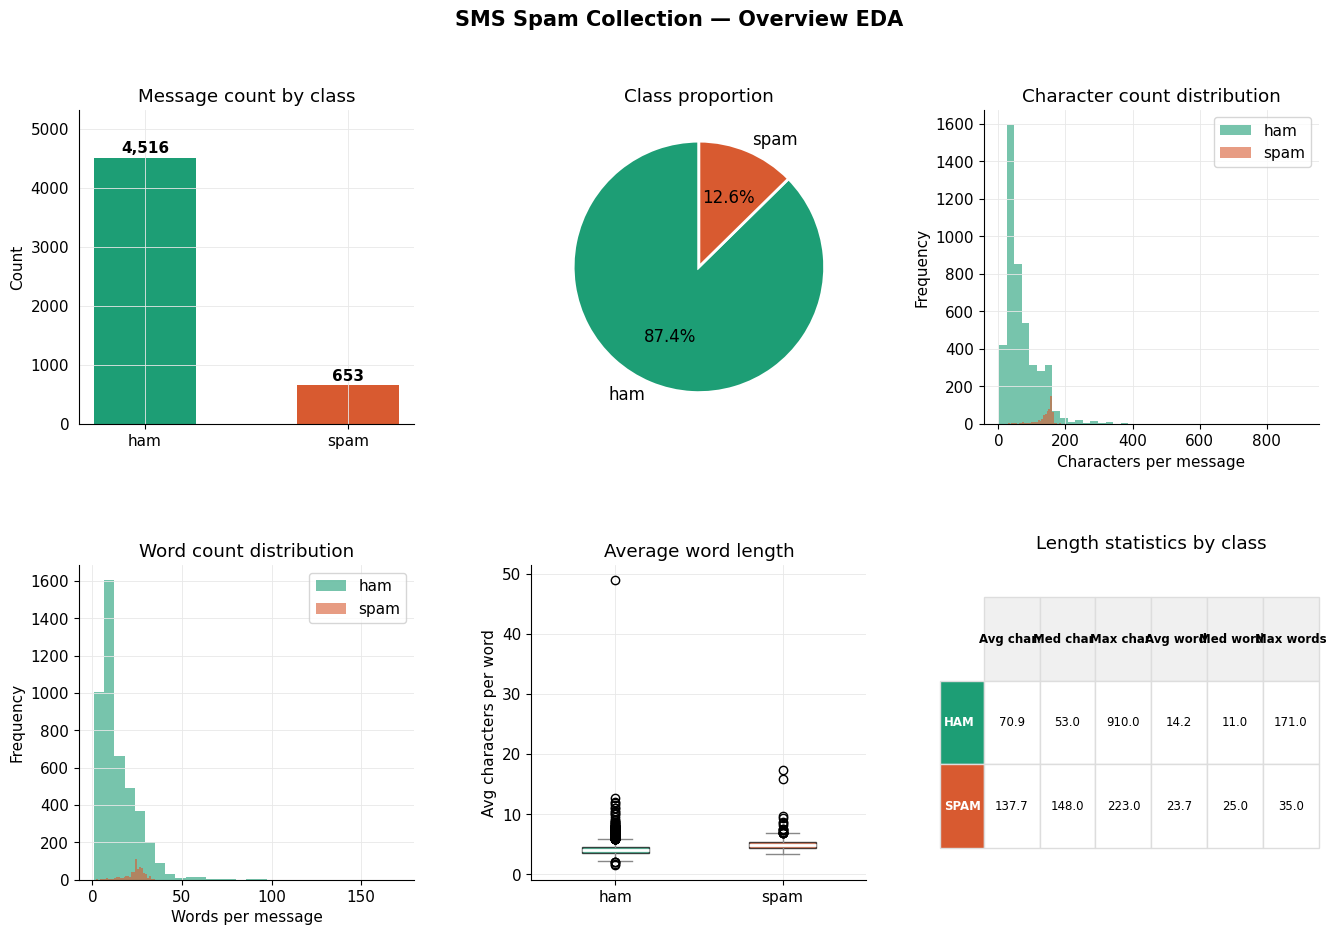

✅ Saved → eda_overview.png


In [14]:
spam_df = df[df["label"] == "spam"]
ham_df  = df[df["label"] == "ham"]

fig = plt.figure(figsize=(16, 10))
fig.suptitle("SMS Spam Collection — Overview EDA", fontsize=15, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1) Count bar
ax1 = fig.add_subplot(gs[0, 0])
counts = df["label"].value_counts()
bars = ax1.bar(counts.index, counts.values,
               color=[PALETTE[l] for l in counts.index], width=0.5, edgecolor="none")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_title("Message count by class")
ax1.set_ylabel("Count")
ax1.set_ylim(0, counts.max() * 1.18)
ax1.tick_params(left=False)

# 2) Pie
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie(counts.values, labels=counts.index,
        colors=[PALETTE[l] for l in counts.index],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 12})
ax2.set_title("Class proportion")

# 3) Char count histogram
ax3 = fig.add_subplot(gs[0, 2])
for label in ["ham", "spam"]:
    ax3.hist(df[df["label"] == label]["char_count"], bins=40,
             alpha=0.6, label=label, color=PALETTE[label], edgecolor="none")
ax3.set_title("Character count distribution")
ax3.set_xlabel("Characters per message")
ax3.set_ylabel("Frequency")
ax3.legend()

# 4) Word count histogram
ax4 = fig.add_subplot(gs[1, 0])
for label in ["ham", "spam"]:
    ax4.hist(df[df["label"] == label]["word_count"], bins=30,
             alpha=0.6, label=label, color=PALETTE[label], edgecolor="none")
ax4.set_title("Word count distribution")
ax4.set_xlabel("Words per message")
ax4.set_ylabel("Frequency")
ax4.legend()

# 5) Avg word length box plot
ax5 = fig.add_subplot(gs[1, 1])
data_box = [ham_df["avg_word_len"].values, spam_df["avg_word_len"].values]
bp = ax5.boxplot(data_box, patch_artist=True, widths=0.4,
                 medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"], [PALETTE["ham"], PALETTE["spam"]]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for el in ["whiskers", "caps", "fliers"]:
    for item in bp[el]: item.set_color("#888")
ax5.set_xticks([1, 2]); ax5.set_xticklabels(["ham", "spam"])
ax5.set_title("Average word length")
ax5.set_ylabel("Avg characters per word")

# 6) Stats table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
stats = df.groupby("label")[["char_count","word_count"]].agg(["mean","median","max"]).round(1)
stats.columns = ["Avg chars","Med chars","Max chars","Avg words","Med words","Max words"]
tbl = ax6.table(cellText=stats.values, rowLabels=stats.index.str.upper(),
                colLabels=stats.columns, cellLoc="center", loc="center",
                bbox=[0, 0.1, 1, 0.8])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#ddd")
    if r == 0:
        cell.set_facecolor("#f0f0f0"); cell.set_text_props(fontweight="bold")
    elif c == -1:
        label_val = stats.index[r - 1]
        cell.set_facecolor(PALETTE.get(label_val, "#fff"))
        cell.set_text_props(color="white", fontweight="bold")
ax6.set_title("Length statistics by class", pad=12)

plt.savefig("eda_plots/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → eda_overview.png")

In [ ]:
#  Violin plots: character & word count 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Message Length Distribution (Violin)", fontsize=13, fontweight="bold")

for ax, col, title in [
    (axes[0], "char_count", "Character count"),
    (axes[1], "word_count",  "Word count"),
]:
    parts = ax.violinplot(
        [ham_df[col].values, spam_df[col].values],
        positions=[1, 2], showmedians=True, showextrema=True
    )
    for pc, label in zip(parts["bodies"], ["ham", "spam"]):
        pc.set_facecolor(PALETTE[label]); pc.set_alpha(0.7)
    parts["cmedians"].set_color("white"); parts["cmedians"].set_linewidth(2)
    for part in ["cbars", "cmins", "cmaxes"]: parts[part].set_color("#888")
    ax.set_xticks([1, 2]); ax.set_xticklabels(["HAM", "SPAM"])
    ax.set_title(title); ax.set_ylabel(title)

plt.tight_layout()
plt.savefig("eda_plots/eda_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → eda_violin.png")

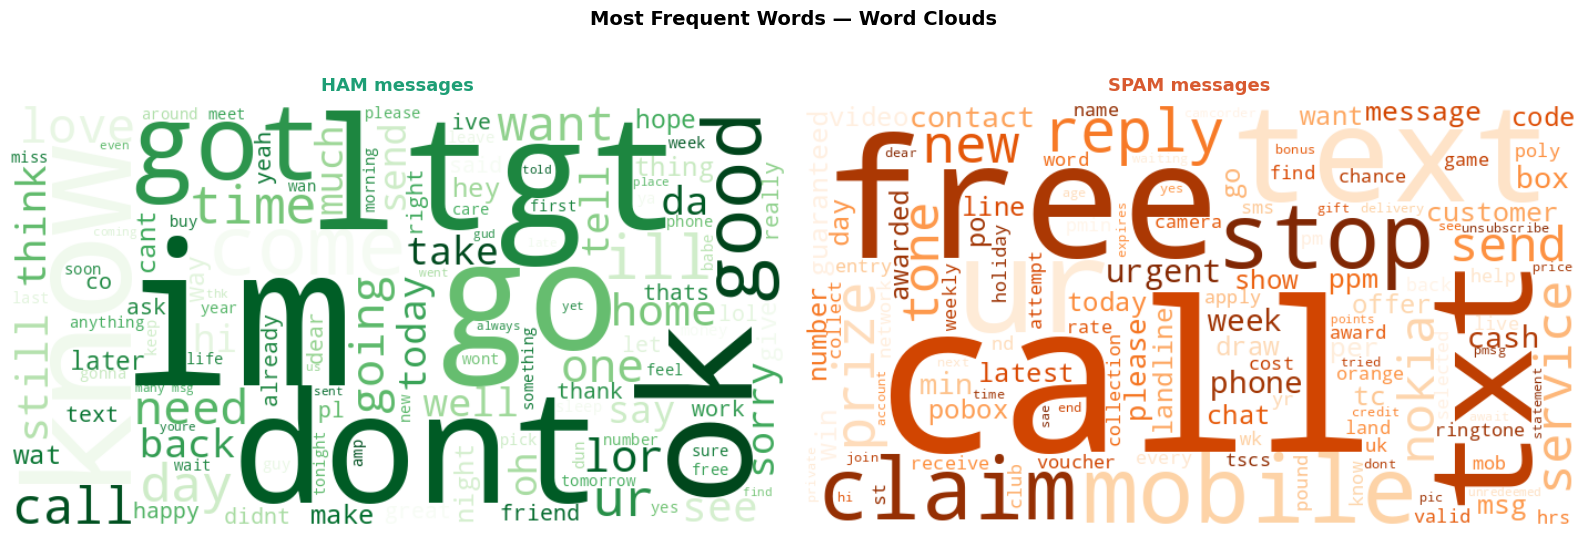

✅ Saved → eda_wordclouds.png


In [15]:
#  Word clouds 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Most Frequent Words — Word Clouds", fontsize=14, fontweight="bold")

for ax, label, cmap in [
    (axes[0], "ham",  "Greens"),
    (axes[1], "spam", "Oranges"),
]:
    corpus = " ".join(df[df["label"] == label]["clean_text"])
    wc = WordCloud(
        width=700, height=380, background_color="white",
        colormap=cmap, max_words=120,
        prefer_horizontal=0.85, collocations=False
    ).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{label.upper()} messages", fontsize=13,
                 fontweight="bold", color=PALETTE[label], pad=10)

plt.tight_layout()
plt.savefig("eda_plots/eda_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → eda_wordclouds.png")

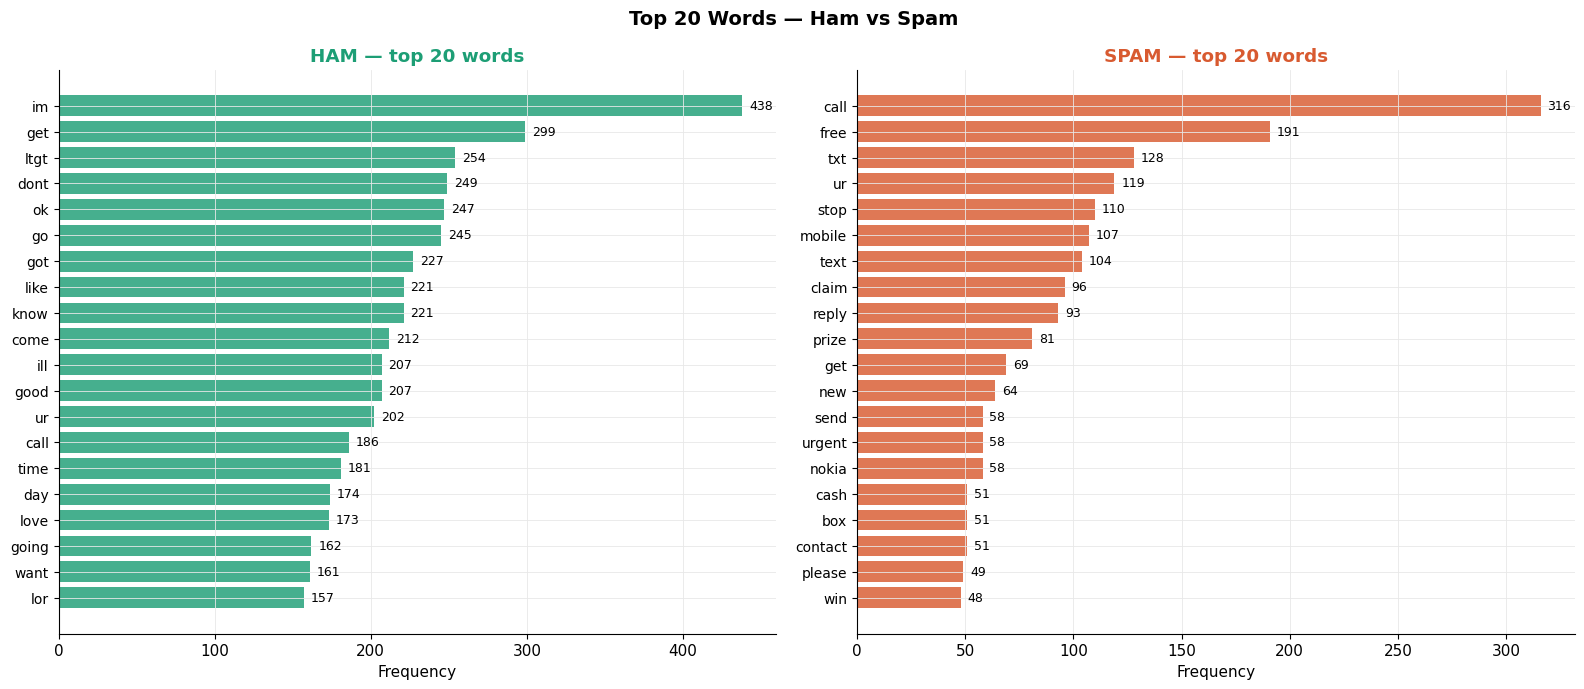

✅ Saved → eda_top_words.png


In [16]:
#  Top-20 words horizontal bar chart 

def top_words(label, n=20):
    words = " ".join(df[df["label"] == label]["clean_text"]).split()
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 20 Words — Ham vs Spam", fontsize=14, fontweight="bold")

for ax, label in [
    (axes[0], "ham"),
    (axes[1], "spam"),
]:
    words, freqs = zip(*top_words(label))
    y = range(len(words))
    ax.barh(y, freqs, color=PALETTE[label], alpha=0.82, edgecolor="none")
    ax.set_yticks(y); ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f"{label.upper()} — top 20 words",
                 fontweight="bold", color=PALETTE[label])
    ax.set_xlabel("Frequency")
    for i, v in enumerate(freqs):
        ax.text(v + max(freqs)*0.01, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("eda_plots/eda_top_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → eda_top_words.png")

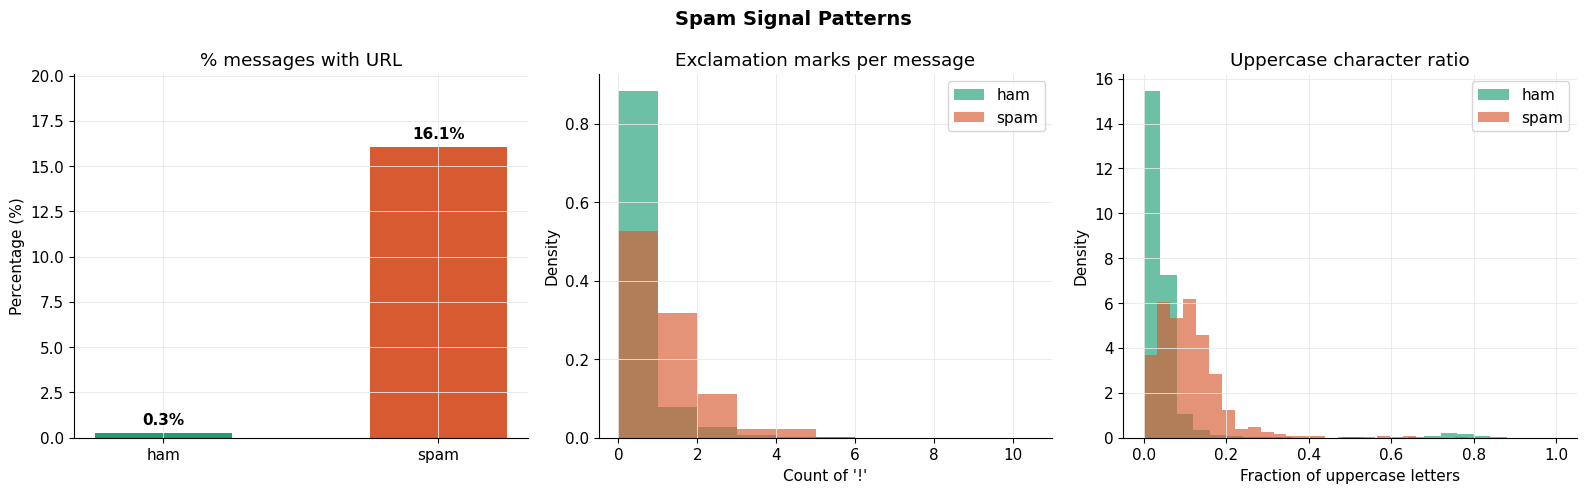

✅ Saved → eda_spam_patterns.png


In [17]:
# Spam pattern plots 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Spam Signal Patterns", fontsize=14, fontweight="bold")

# 1) URL presence
ax = axes[0]
url_pct = df.groupby("label")["url"].mean() * 100
bars = ax.bar(url_pct.index, url_pct.values,
              color=[PALETTE[l] for l in url_pct.index], width=0.5, edgecolor="none")
for bar, val in zip(bars, url_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("% messages with URL")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, url_pct.max() * 1.25)

# 2) Exclamation mark distribution
ax = axes[1]
for label in ["ham", "spam"]:
    ax.hist(df[df["label"] == label]["exclaim_count"],
            bins=range(0, 12), alpha=0.65, label=label,
            color=PALETTE[label], edgecolor="none", density=True)
ax.set_title("Exclamation marks per message")
ax.set_xlabel("Count of '!'")
ax.set_ylabel("Density")
ax.set_xlim(-0.5, 11)
ax.legend()

# 3) Uppercase ratio distribution
ax = axes[2]
for label in ["ham", "spam"]:
    ax.hist(df[df["label"] == label]["uppercase_ratio"],
            bins=25, alpha=0.65, label=label,
            color=PALETTE[label], edgecolor="none", density=True)
ax.set_title("Uppercase character ratio")
ax.set_xlabel("Fraction of uppercase letters")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig("eda_plots/eda_spam_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → eda_spam_patterns.png")

In [18]:
# ── Digit presence comparison ─────────────────────────────────────────────────
digit_pct = df.groupby("label")["number"].mean() * 100
print("Messages containing at least one digit:")
for label, pct in digit_pct.items():
    print(f"  {label.upper():<6}: {pct:.1f}%")

print(f"\nAverage '!' per message:")
exclaim_avg = df.groupby("label")["exclaim_count"].mean()
for label, avg in exclaim_avg.items():
    print(f"  {label.upper():<6}: {avg:.2f}")

Messages containing at least one digit:
  HAM   : 15.8%
  SPAM  : 94.0%

Average '!' per message:
  HAM   : 0.18
  SPAM  : 0.70


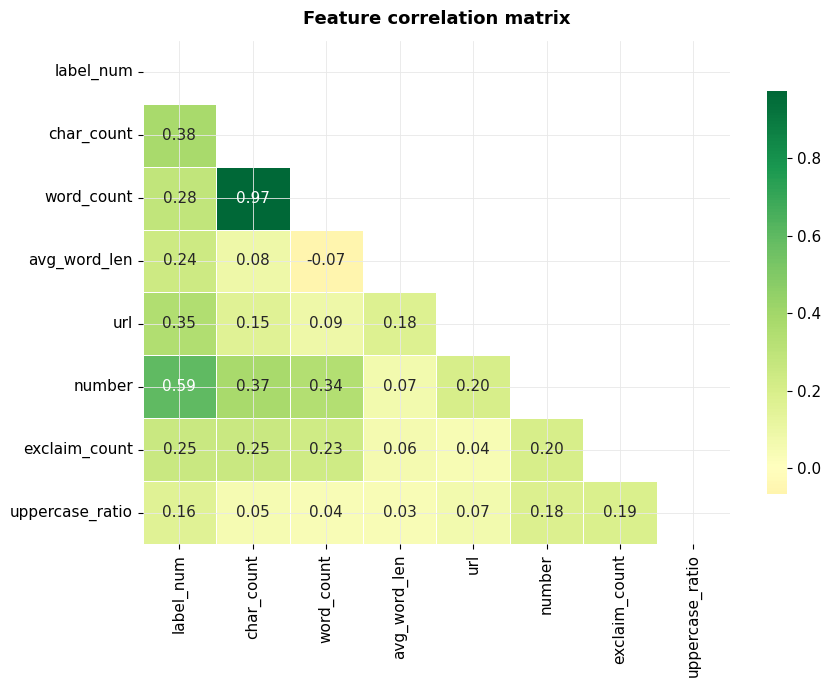

✅ Saved → eda_correlation.png


In [19]:
# ── Correlation matrix ────────────────────────────────────────────────────────
num_cols = ["label_num", "char_count", "word_count", "avg_word_len",
            "url", "number", "exclaim_count", "uppercase_ratio"]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("eda_plots/eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → eda_correlation.png")

In [20]:
# ── Top correlations with label ───────────────────────────────────────────────
corr_with_label = (corr["label_num"]
                   .drop("label_num")
                   .abs()
                   .sort_values(ascending=False))

print("Features ranked by |correlation| with spam label:")
for feat, val in corr_with_label.items():
    print(f"  {feat:<20}: {val:.3f}")

Features ranked by |correlation| with spam label:
  number              : 0.595
  char_count          : 0.380
  url                 : 0.351
  word_count          : 0.284
  exclaim_count       : 0.255
  avg_word_len        : 0.242
  uppercase_ratio     : 0.159


saving cleaned csv


In [ ]:
# Save cleaned CSV 
OUTPUT_CSV = "data/cleaned/sms_spam_cleaned.csv"
data/cleaned
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Cleaned dataset saved → {OUTPUT_CSV}")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")

OSError: Cannot save file into a non-existent directory: 'data/cleaned'